In [58]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from oitg import uncertainty_to_string
from oitg.results import load_result
import graph_style as gs
gs.set_graph_style(1.0)


def load_data(rid, day):
    f = load_result(rid=rid, day=day, experiment="fastgates")
    print(f["datasets"].keys())
    x = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_0"])
    y = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_1"])
    p = np.array(
        f["datasets"][f"ndscan.rid_{rid}.points.channel_measurement_camera_readout_p"]
    )
    return x, y, p


date = "2025-07-24"
rid = 43553
x, y, p = load_data(rid, date)


dict_keys(['ndscan.rid_43553.analysis_results', 'ndscan.rid_43553.annotations', 'ndscan.rid_43553.axes', 'ndscan.rid_43553.channels', 'ndscan.rid_43553.completed', 'ndscan.rid_43553.fragment_fqn', 'ndscan.rid_43553.ndscan_schema_revision', 'ndscan.rid_43553.online_analyses', 'ndscan.rid_43553.points.axis_0', 'ndscan.rid_43553.points.axis_1', 'ndscan.rid_43553.points.channel_crystal_check_readout_counts', 'ndscan.rid_43553.points.channel_crystal_check_readout_is_brights', 'ndscan.rid_43553.points.channel_measurement_camera_readout_p', 'ndscan.rid_43553.points.channel_measurement_camera_readout_p_0', 'ndscan.rid_43553.points.channel_measurement_camera_readout_p_err', 'ndscan.rid_43553.points.channel_measurement_camera_readout_p_err_0', 'ndscan.rid_43553.points.channel_measurement_crystal_p', 'ndscan.rid_43553.points.channel_measurement_crystal_p_0', 'ndscan.rid_43553.points.channel_measurement_crystal_p_err', 'ndscan.rid_43553.points.channel_measurement_crystal_p_err_0', 'ndscan.rid_4355

In [59]:
x_unique = np.unique(x)
y_unique = np.unique(y)
nx, ny = len(x_unique), len(y_unique)

# Flatten the arrays first
x_flat = x.flatten()
y_flat = y.flatten()
p_flat = p.flatten()

# Create structured array properly
dt = np.dtype([("x", float), ("y", float), ("p", float)])
data = np.empty(len(x_flat), dtype=dt)
data["x"] = x_flat
data["y"] = y_flat
data["p"] = p_flat

sorted_data = np.sort(data, order=["y", "x"])

x = sorted_data["x"].reshape(ny, nx)
y = sorted_data["y"].reshape(ny, nx)
p = sorted_data["p"].reshape(ny, nx)

Gaussian fit parameters:
Amplitude: 0.955
Center (x0, y0): (-0.077, 0.024)
waist_x: (1.584+-0.003)
waist_y: (1.386+-0.002)
Offset: 0.009


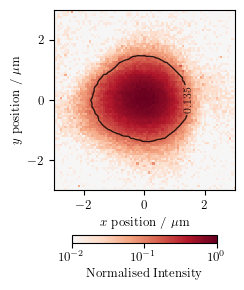

In [100]:
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm
from scipy.ndimage import median_filter

intensity = np.arcsin(1 - p) ** 2
intensity = np.acos(np.sqrt(p))**2

filtered = median_filter(intensity, size=4)
diff = np.abs(intensity - filtered)
mask = diff > 20 * np.median(diff)
intensity[mask] = filtered[mask]
intensity /= np.max(np.abs(intensity))


def gaussian_2d(xy, amp, x0, y0, waist_x, waist_y, offset):
    x, y = xy
    return amp * (np.exp(
        -(2*(x - x0) ** 2 / ( waist_x**2) + 2*(y - y0) ** 2 / ( waist_y**2))
    )) + offset

popt, pcov = curve_fit(
    gaussian_2d,
    (x.flatten(), y.flatten()),
    intensity.flatten(),
    p0=[1, 0, 0, 1, 1, 1],
)
perrs = np.sqrt(np.diag(pcov))


print(f"Gaussian fit parameters:\n"
      f"Amplitude: {popt[0]:.3f}\n"
      f"Center (x0, y0): ({popt[1]:.3f}, {popt[2]:.3f})\n"
      f"waist_x: ({popt[3]:.3f}+-{perrs[3]:.3f})\n"
      f"waist_y: ({popt[4]:.3f}+-{perrs[4]:.3f})\n"
      f"Offset: {popt[5]:.3f}")


cmap_full = plt.cm.RdBu_r
cmap_truncated = LinearSegmentedColormap.from_list(
    "white_to_red", cmap_full(np.linspace(0.5, 1.0, 512))
)

factor = 4
intensity_blurred = median_filter(intensity, size=factor)

fig_width = gs.get_fig_width()*0.4
fig_height = fig_width *5
plt.figure(figsize=(fig_width, fig_height))
im = plt.pcolormesh(
    x,
    y,
    intensity,
    cmap=cmap_truncated,
    norm=SymLogNorm(linthresh=0.01, vmin=1e-2, vmax=1)
)
# upscale and gaussian blur

# add 1/e^2 label on contour
text = f"    {1/(np.e)**2:.3f}    "
ctr  = plt.contour(
    x, y, intensity_blurred, levels=[1/(np.e)**2], colors="black", alpha=0.8
)
plt.clabel(ctr, fmt=text, inline=True, fontsize=8, colors="black", inline_spacing=60)
cbar = plt.colorbar(im, orientation='horizontal', fraction=0.15, pad=0.05, aspect=20, shrink=0.8)
cbar.set_label("Normalised Intensity")
plt.xlabel(r"$x$ position / $\mu$m")
plt.ylabel(r"$y$ position / $\mu$m")
plt.gca().set_aspect("equal")
extent = 3
plt.xlim(-extent, extent)
plt.ylim(-extent, extent)
plt.xticks([-2,0,2])
plt.yticks([-2,0,2])
plt.grid(None)
f_name = "..\\..\\pdf_figure\\ch4\\sa_2D.pdf"
# plt.savefig(f_name, bbox_inches="tight", dpi=300)

Gaussian fit parameters:
Amplitude: 0.955
Center (x0, y0): (-0.077, 0.024)
Sigma (waist_x, waist_y): (1.120, 0.980)
Offset: 0.009
